In [341]:
import os
import importlib
import pickle
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from together import Together

import time
from datetime import timedelta
from tqdm import tqdm

import math_parser 
importlib.reload(math_parser)
from math_parser import *

# Setting Up

In [7]:
def save_object(x, file_path):
    with open(file_path, 'wb') as file:
        pickle.dump(x, file)

def load_object(file_path):
    with open(file_path, 'rb') as file:
        x = pickle.load(file)
    return x

def save_json(x, file_path):
    with open(file_path, 'w') as json_file:
        json.dump(x, json_file, indent=4)

def load_json(file_path):
    with open(file_path, 'r') as json_file:
        x = json.load(json_file)
    return x

In [25]:
api_key = os.getenv('TogetherAI_API_Key')
client = Together(api_key=api_key)
model = "meta-llama/Llama-3.3-70B-Instruct-Turbo"
few_shot_messages = load_json('./few_shot_examples.json')

# global settings
random.seed(42)
n_ver_questions = 2
n_break_step = 10
cove_result = {
    'is_correct': [], 
    'response': []
}

In [8]:
def create_user_msg(s):
    return [{"role": "user", "content": s}]

def append_user_msg(s, messages):
    messages.append({"role": "user", "content": s})

def chat_and_update_history(model, messages):
    response = client.chat.completions.create(model=model, messages=messages)
    response_context = {"role": "assistant", "content": response.choices[0].message.content}
    messages.append(response_context)

# Importing MATH Data

In [11]:
math_data = pd.read_parquet('./data/MATH.parquet')
# removing '?' level
math_data = math_data[math_data['level'] != 'Level ?']
_, math_samp = train_test_split(math_data, test_size=0.0042, stratify=math_data[['level', 'type']], random_state=42)
math_ex = math_samp.sample(3, replace=False, random_state=42)
math_samp = math_samp.drop(index=math_ex.index)
math_ex = math_ex.reset_index(drop=True)
math_samp = math_samp.reset_index(drop=True)

# Baseline

In [330]:
start_time = time.time()
result = {
    'is_correct': [], 
    'response': []
}
for i in tqdm(range(math_samp.shape[0])):
    messages = create_user_msg(f"Solve the problem P and box the final, simplified answer with the LaTeX command \\boxed{{...}}.\nP: {math_samp.loc[i, 'problem']}")
    chat_and_update_history(model, messages)
    result['is_correct'].append(is_correct(math_samp.loc[i, 'solution'], messages[1]['content']))
    result['response'].append(messages[1]['content'])

end_time = time.time()
print(f"Total time: {str(timedelta(seconds=round(end_time - start_time)))}")
result = pd.DataFrame(result)

  8%|▊         | 4/50 [00:46<08:50, 11.53s/it]


KeyboardInterrupt: 

In [58]:
# save_object(result, './result_base.pkl')
result = load_object('./base_result.pkl')

# CoVe

In [313]:
start_time = time.time()
box_final_result = {
    'is_correct': [], 
    'response': []
}
for i in tqdm(range(math_samp.shape[0])):
    # setting up variables for the problem
    problem = f"P: {math_samp.loc[i, 'problem']}"
    step_list = []
    steps = '\n\n'.join(step_list)
    step_num = 0
    is_partial_answer = True
    while is_partial_answer:
        # setting up conditionals for the loop
        is_partial_answer = not "\\boxed" in steps
        if (not is_partial_answer) or step_num >= n_break_step:
            break
        if step_num == 0:
            answer_str = "" 
        elif is_partial_answer:
            answer_str = " and solution A"

        # generate new step
        gen_step_messages = copy.deepcopy(few_shot_messages)
        gen_step_messages = gen_step_messages['gen_step']
        gen_step_instruct = f"Given a problem P{answer_str}, generate only the next step (Step {step_num+1}). Rules:\n- Build directly on the last verified step's output\n- Do NOT describe what you will do — do it\n- Do NOT reference future steps\n- Box the final, simplified answer with the LaTeX command \\boxed{{...}}."
        gen_step_pa = f"{problem}"
        if step_num != 0:
            gen_step_pa += f"\nA: {steps}"
        gen_step_input = '\n'.join([gen_step_instruct, gen_step_pa])
        append_user_msg(gen_step_input, gen_step_messages)
        chat_and_update_history(model, gen_step_messages)

        # update steps
        step_list.append(gen_step_messages[-1]['content'])
        steps = '\n\n'.join(step_list)

        # generating verification step
        gen_ver_messages = copy.deepcopy(few_shot_messages)
        gen_ver_messages = gen_ver_messages['gen_ver']
        gen_ver_instruct = f"Given a problem P{answer_str}, write verification questions that checks whether the claims or math operations in {step_num+1} are correct. Only output the questions as a semicolon separated list and ensure that each question is self-contained and independent of each other."
        gen_ver_qa = f"{problem}\nA: {steps}"
        gen_ver_input = '\n'.join([gen_ver_instruct, gen_ver_qa])
        append_user_msg(gen_ver_input, gen_ver_messages)
        chat_and_update_history(model, gen_ver_messages)

        # sampling verification questions
        ver_questions = gen_ver_messages[-1]['content'].split('; ')
        if n_ver_questions < len(ver_questions):
            ver_questions = random.sample(ver_questions, n_ver_questions)

        # cutting out step to verify
        ver_steps = '\n\n'.join(step_list[:-1])

        # verify and revise step
        for j in range(len(ver_questions)):
            # answering verifying questions independently
            ver_messages = copy.deepcopy(few_shot_messages)
            ver_messages = ver_messages['ver']
            ver_instruct = f"Concisely answer the question given the context of problem P{answer_str}."
            ver_qc = f"Question: {ver_questions[j]}\nContext: {problem}"
            if step_num != 0:
                ver_qc += f"\nA: {ver_steps}"
            ver_input = '\n'.join([ver_instruct, ver_qc])
            append_user_msg(ver_input, ver_messages)
            chat_and_update_history(model, ver_messages)

            # revising step using verification question and answer
            rev_messages = copy.deepcopy(few_shot_messages)
            rev_messages = rev_messages['rev']
            rev_instruct = f"Consider Step {step_num+1} within the context. Only output \"INCONSISTENT\" if there is a direct, specific numerical or logical contradiction within the context. Do not mark it \"INCONSISTENT\" for any of the following reasons: the step could be phrased more clearly, the step skips an explanation you would include, the step uses different (but equivalent) notation, or you would have approached it differently. Also output a revised Step {step_num+1}. Otherwise, output \"CONSISTENT\" and the original {step_num+1}."
            rev_co = f"Context: Q: {ver_questions[j]}\nA: {ver_messages[-1]['content']}\nOriginal: {problem}\nA: {steps}"
            rev_input = '\n'.join([rev_instruct, rev_co])
            append_user_msg(rev_input, rev_messages)
            chat_and_update_history(model, rev_messages)

            # checking for inconsistency and revising
            if "INCONSISTENT" in rev_messages[-1]['content']:
                new_step = '\n\n'.join(rev_messages[-1]['content'].split('\n\n')[1:])
                step_list[-1] = new_step 
                steps = '\n\n'.join(step_list)
            
        # checking to box final answer
        check_final_instruct = f"Check if this step (Step {step_num+1}) contains the final answer to the question. If not, then return only the word 'NO'. If the answer to the question is in this step, then box only the simplified answer with \"\\boxed{...}\" in the step and return the step without changing anything else."
        check_final_pa = f"{problem}\nA: {step_list[-1]}"
        check_final_input = '\n'.join([check_final_instruct, check_final_pa])
        check_final_messages = create_user_msg(check_final_input)
        chat_and_update_history(model, check_final_messages)

        if 'NO' not in check_final_messages[-1]['content']:
            step_list[-1] = check_final_messages[-1]['content']
            steps = '\n\n'.join(step_list)
        
        # moving on to generate next step
        step_num += 1

    # if stuck in loop, then mark the question as wrong
    if step_num >= n_break_step:
        steps = ""
    
    box_final_result['response'].append(steps)
    box_final_result['is_correct'].append(is_correct(math_samp.loc[i, 'solution'], steps))

end_time = time.time()
print(f"Total time: {str(timedelta(seconds=round(end_time - start_time)))}")
box_final_result = pd.DataFrame(box_final_result)

100%|██████████| 50/50 [18:37<00:00, 22.34s/it]

Total time: 0:18:37


In [329]:
sum(base_result['is_correct']) / base_result.shape[0]

0.88

In [314]:
sum(box_final_result['is_correct']) / box_final_result.shape[0]

0.9

In [315]:
save_object(box_final_result, './box_final_result.pkl')

In [350]:
cm = pd.crosstab(base_result['is_correct'], box_final_result['is_correct'], rownames=['Baseline'], colnames=['CoVe'])
cm.iloc[::-1, ::-1]

CoVe,True,False
Baseline,,
True,42,2
False,3,3


# Graphics

In [337]:
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'font.size':         9,
    'axes.titlesize':    9,
    'axes.labelsize':    8,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'axes.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'legend.fontsize':   7,
    'legend.frameon':    False,
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.05,
})

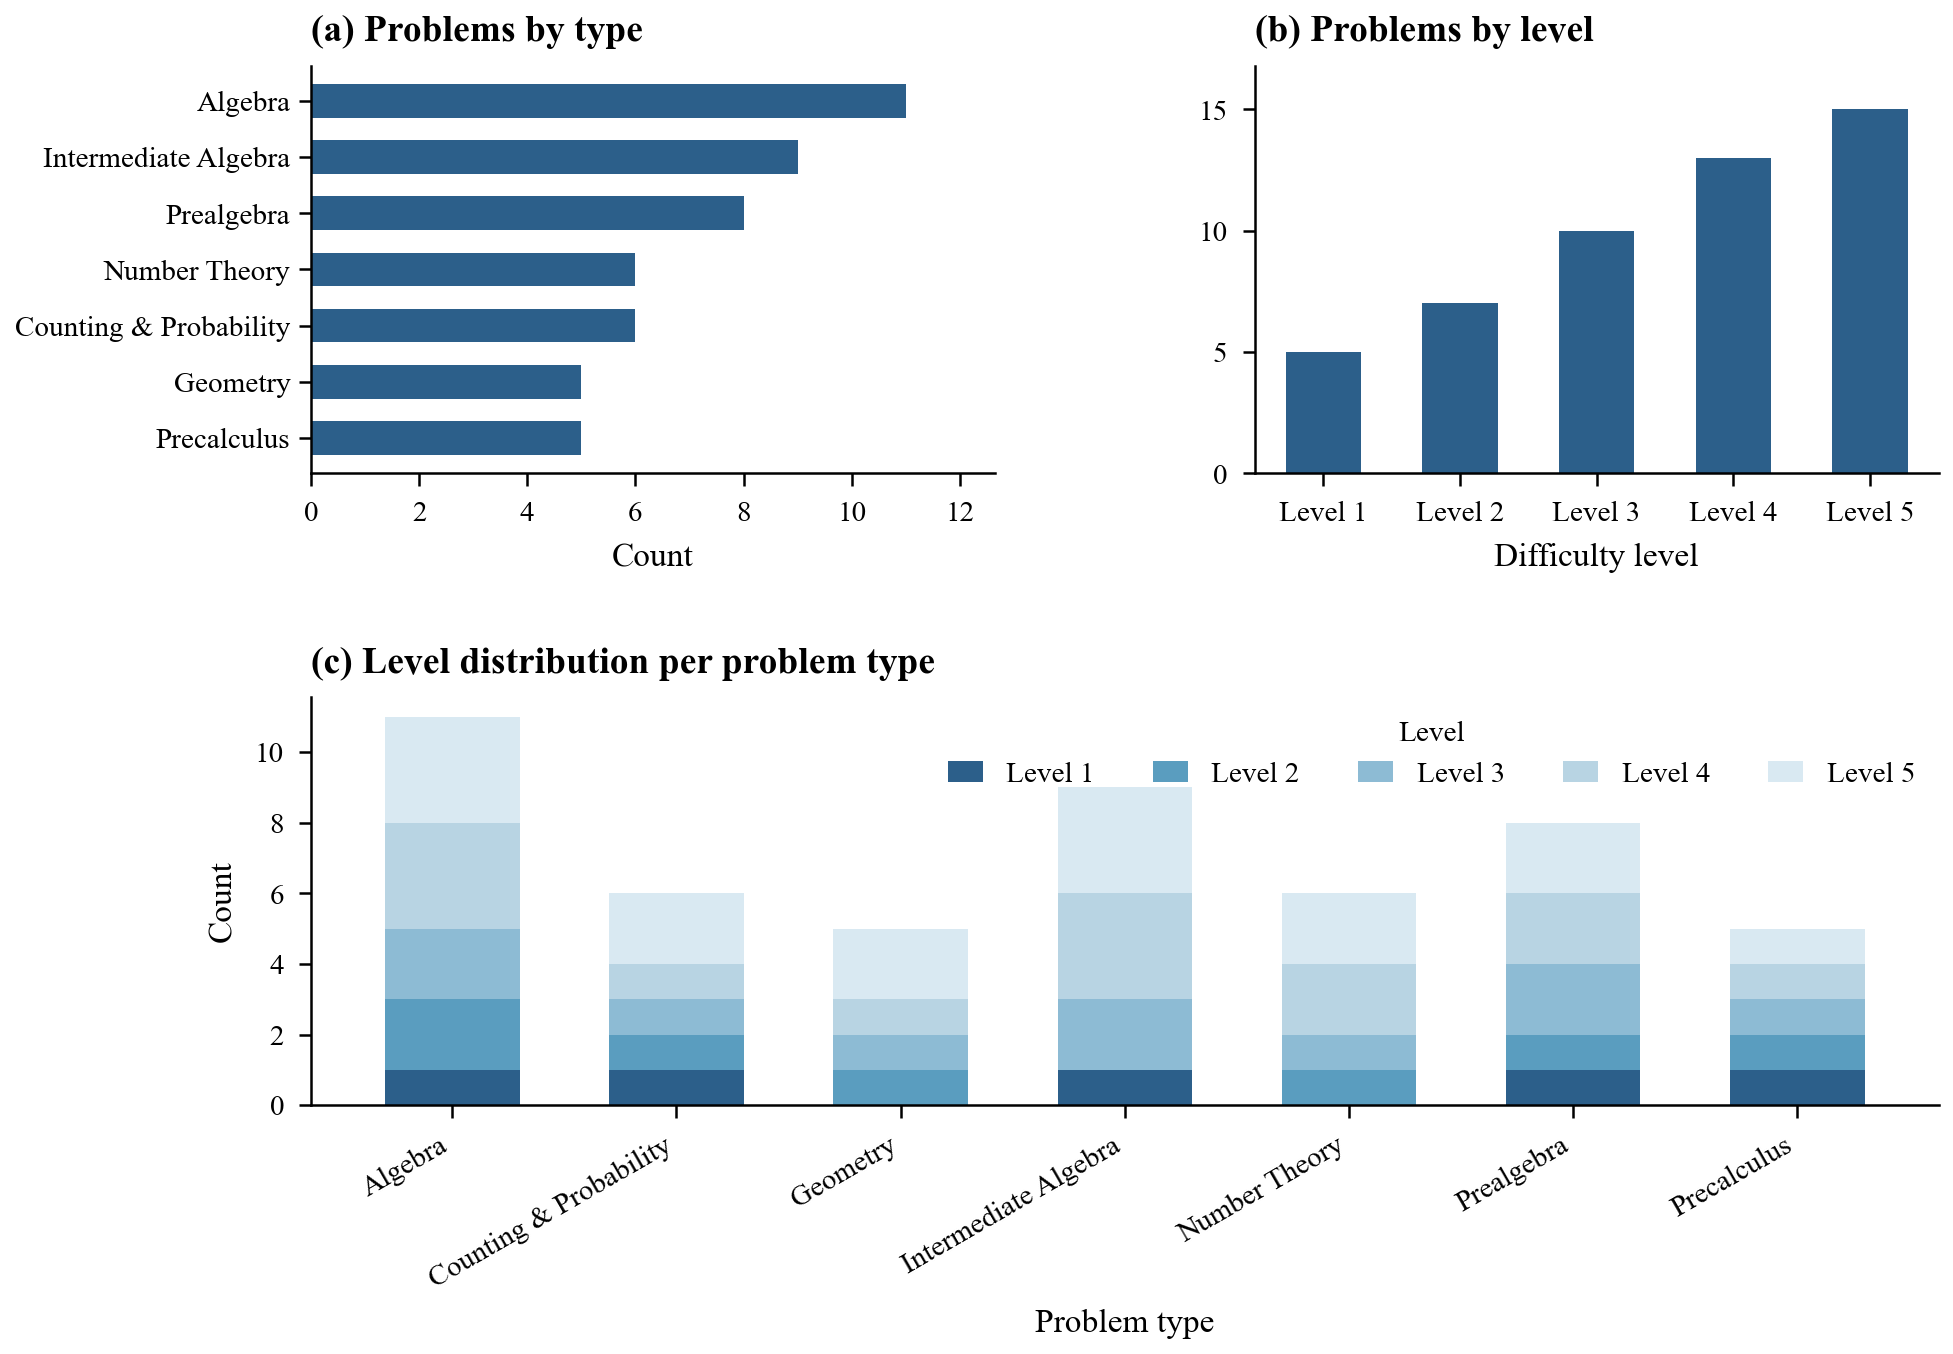

In [362]:
COLORS = ['#2c5f8a', '#5a9dbf', '#8dbbd4', '#b8d4e3', '#d9e9f2']

type_counts  = math_samp['type'].value_counts()
level_counts = math_samp['level'].value_counts().sort_index()
type_level   = math_samp.groupby(['type', 'level']).size().unstack(fill_value=0)

fig = plt.figure(figsize=(7, 4.5))  # NeurIPS single-column width ~3.3in, double ~7in
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.38)

# Plot bar of problems by type
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(type_counts.index, type_counts.values,
                color=COLORS[0], height=0.6)
ax1.set_title('(a) Problems by type', loc='left', fontweight='bold')
ax1.set_xlabel('Count')
ax1.invert_yaxis()
for bar, val in zip(bars, type_counts.values):
    ax1.text(val + 15, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=6.5)
ax1.set_xlim(0, type_counts.max() * 1.15)
ax1.tick_params(axis='y', pad=2)

# Plot bar of problems by level
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(level_counts))
bars2 = ax2.bar(x, level_counts.values, color=COLORS[0], width=0.55)
ax2.set_title('(b) Problems by level', loc='left', fontweight='bold')
ax2.set_xlabel('Difficulty level')
ax2.set_xticks(x)
ax2.set_xticklabels(level_counts.index.astype(str))
ax2.set_ylim(0, level_counts.max() * 1.12)

# Plot 3 stacked bar of level breakdown per type 
ax3 = fig.add_subplot(gs[1, :])
bottom = np.zeros(len(type_level))
level_cols = sorted(type_level.columns)
for i, level in enumerate(level_cols):
    vals = type_level[level].values
    ax3.bar(np.arange(len(type_level)), vals, bottom=bottom,
            label=str(level), color=COLORS[i], width=0.6)
    bottom += vals

ax3.set_title('(c) Level distribution per problem type', loc='left', fontweight='bold')
ax3.set_xlabel('Problem type')
ax3.set_ylabel('Count')
ax3.set_xticks(np.arange(len(type_level)))
ax3.set_xticklabels(type_level.index, rotation=30, ha='right', fontsize=7)
ax3.legend(title='Level', ncol=5, loc='upper right',
           title_fontsize=7, borderpad=0.3, handlelength=1.2)

plt.savefig('math_samp_neurips.png')
plt.show()

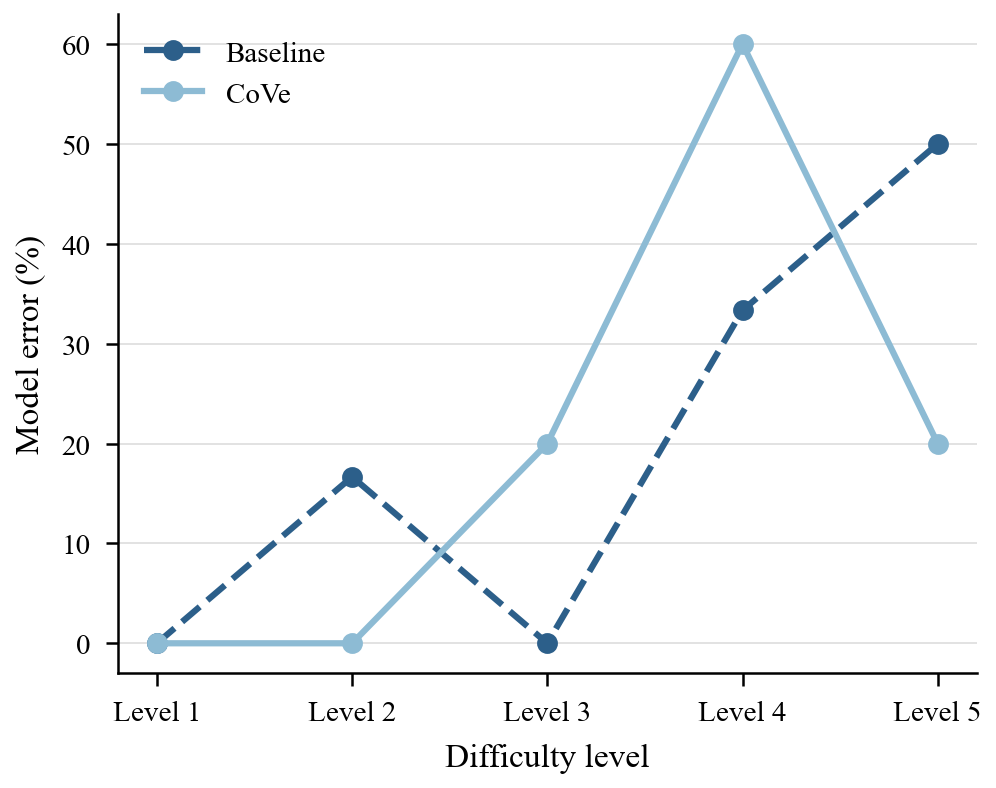

In [360]:
# Preparing data
all_levels = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

box_wrong = pd.merge(box_final_result, math_samp, left_index=True, right_index=True).loc[~box_final_result['is_correct']]
base_wrong = pd.merge(base_result,      math_samp, left_index=True, right_index=True).loc[~base_result['is_correct']]

box_counts = box_wrong['level'].value_counts().reindex(all_levels, fill_value=0)
base_counts = base_wrong['level'].value_counts().reindex(all_levels, fill_value=0)

box_total = box_counts.sum()
base_total = base_counts.sum()

x = np.arange(len(all_levels))
width = 0.35
BLUE = '#2c5f8a'
STEEL = '#8dbbd4'

fig2, ax2 = plt.subplots(figsize=(3.5, 2.8))
base_pct = base_counts.values / base_total * 100
box_pct  = box_counts.values  / box_total  * 100
ax2.plot(all_levels, base_pct, marker='o', markersize=4, linewidth=1.5,
         color='#2c5f8a', label='Baseline', linestyle='--')
ax2.plot(all_levels, box_pct,  marker='o', markersize=4, linewidth=1.5,
         color='#8dbbd4', label='CoVe')
ax2.set_xlabel('Difficulty level')
ax2.set_ylabel("Model error (%)")
ax2.yaxis.grid(True, linewidth=0.4, color='#ddd', zorder=0)
ax2.set_axisbelow(True)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig2b_errors_pct.png')
plt.show()